## EDA Reference — Customer Churn Classification

### Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
train_df = pd.read_csv ("../data/churn_train.csv")
test_df = pd.read_csv ("../data/churn_test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (440833, 12)
Test shape:  (64374, 12)


### Data Types & Info

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [4]:
train_df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [5]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


### Check Missing Values & Duplicates

In [ ]:
# Missing value 

missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2) 

missing_report = pd.DataFrame({"Missing": missing, "Percent (%)": missing_pct})
print(missing_report[missing_report["Missing"] > 0] if missing.sum() > 0 else "No missing value")

In [6]:
# Duplicates
dup_count = train_df.duplicated().sum()
print("Duplicates: ", dup_count)

Duplicates:  0


In [7]:
# Xem dòng bị missing
null_rows = train_df[train_df.isnull().any(axis=1)]
print(f"Số dòng bị missing: {len(null_rows)}")
print(f"Index: {null_rows.index.tolist()}")
null_rows

Số dòng bị missing: 1
Index: [199295]


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Churn Distribution (Target Variable)

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


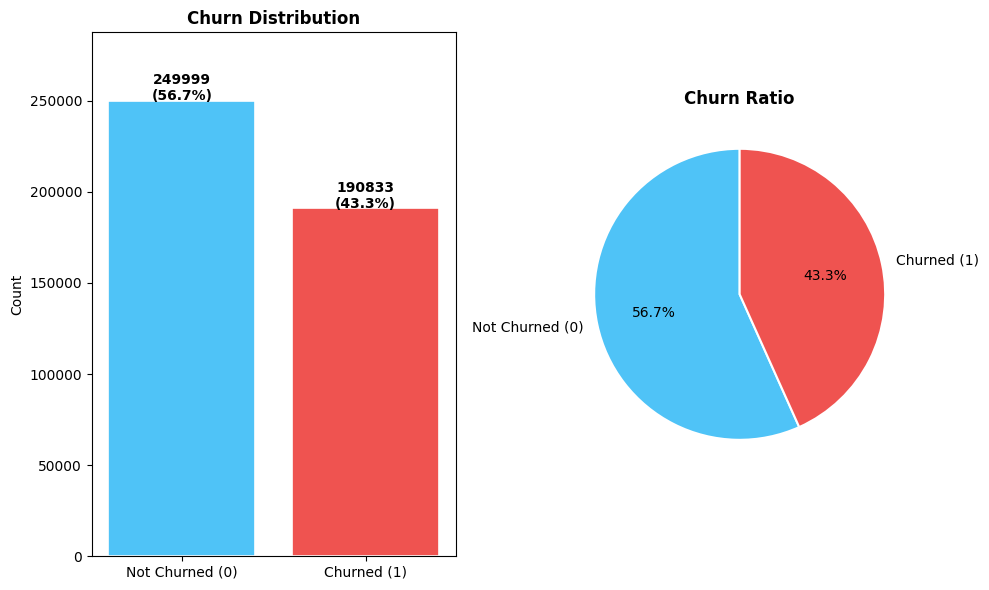

In [8]:
churn_counts = train_df["Churn"].value_counts()
churn_pct = train_df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
colors = ["#4FC3F7", "#EF5350"]
labels = ["Not Churned (0)", "Churned (1)"]

# Bar Chart 
axes[0].bar(labels, churn_counts.values, color=colors, edgecolor="white", linewidth=1.2)
for i, (cnt, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, cnt + 100, f"{cnt}\n({pct:.1f}%)", ha="center", fontweight="bold")
    
axes[0].set_title("Churn Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].margins(y=0.15)

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Churn Ratio", fontweight="bold")
plt.tight_layout()
plt.show()


### Numerical Feature Distributions

Vẽ histogram cho từng numerical feature để hiểu phân bố:
- Phân bố có đều không? (uniform, normal, skewed?)
- Có outlier không?
- Range giá trị ra sao?

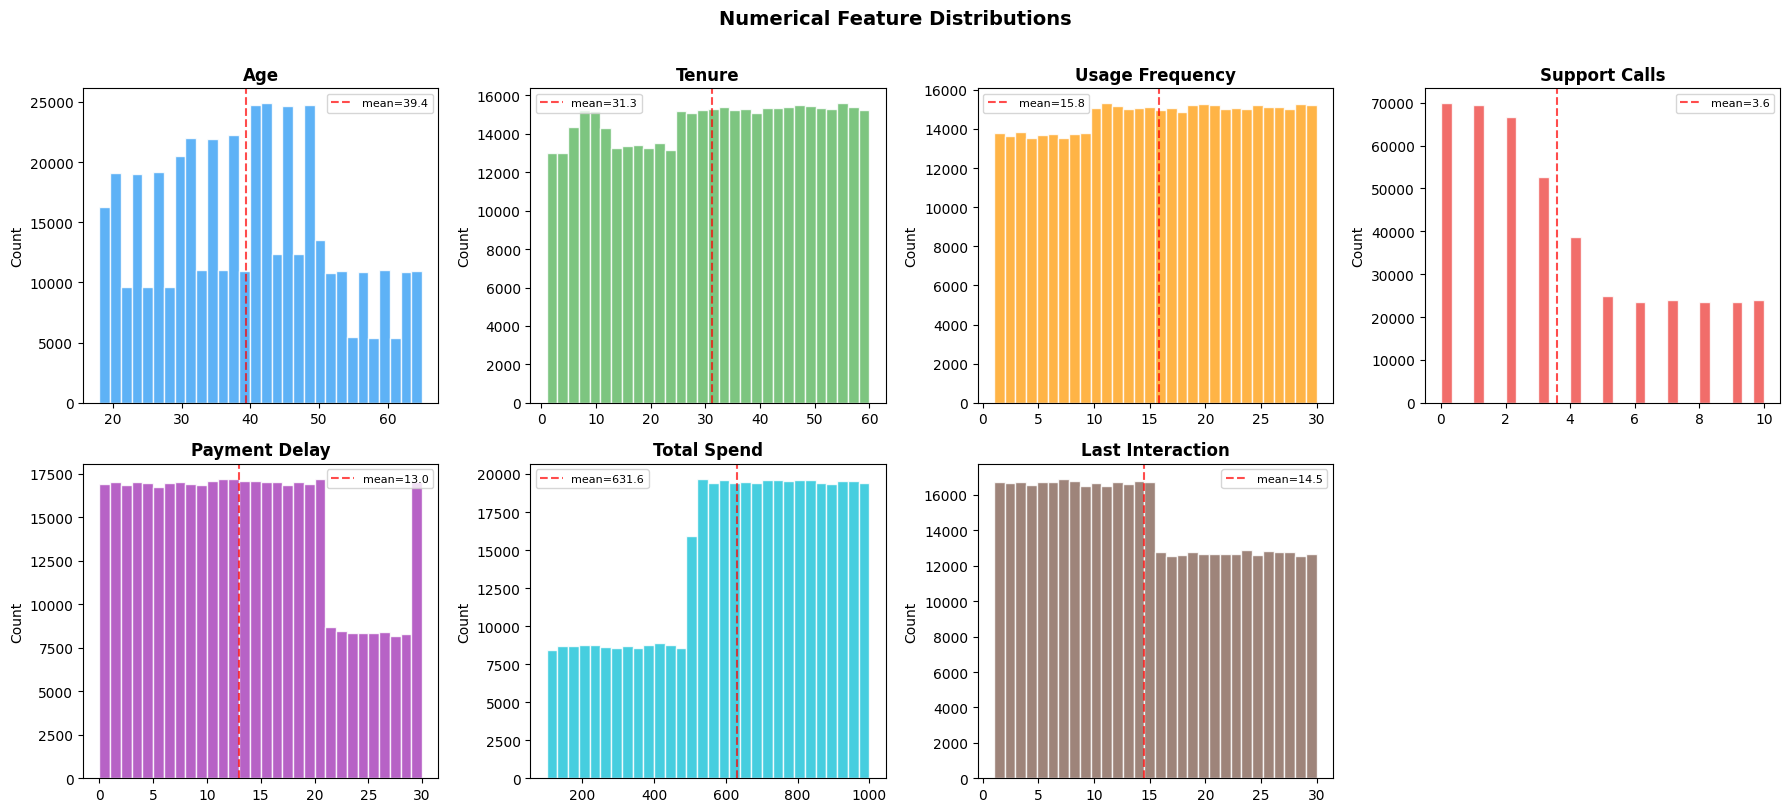

In [11]:
num_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls",
            "Payment Delay", "Total Spend", "Last Interaction"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colors = ["#42A5F5", "#66BB6A", "#FFA726", "#EF5350",
          "#AB47BC", "#26C6DA", "#8D6E63"]

for i, col in enumerate(num_cols):
    ax = axes[i // 4][i % 4]
    ax.hist(train_df[col].dropna(), bins=30, color=colors[i],
            edgecolor="white", alpha=0.85)
    ax.set_title(col, fontweight="bold", fontsize=12)
    ax.set_ylabel("Count")
    
    # mean
    mean_val = train_df[col].mean()
    ax.axvline(mean_val, color="red", linestyle="--", alpha=0.7, label=f"mean={mean_val:.1f}")
    ax.legend(fontsize=8)

axes[1][3].set_visible(False)
plt.suptitle("Numerical Feature Distributions", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Categorical Feature Distributions

Vẽ bar chart cho categorical features để xem phân bố giữa các nhóm.

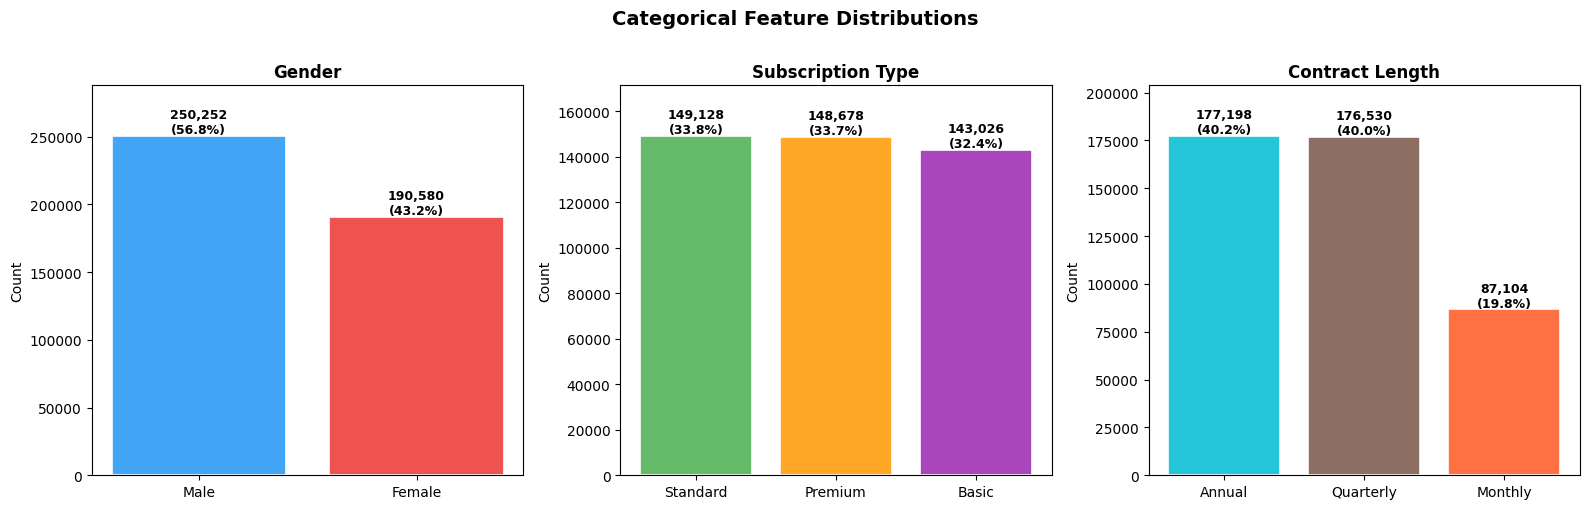

In [12]:
cat_cols = ["Gender", "Subscription Type", "Contract Length"]
cat_colors = [["#42A5F5", "#EF5350"],
              ["#66BB6A", "#FFA726", "#AB47BC"],
              ["#26C6DA", "#8D6E63", "#FF7043"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(cat_cols):
    counts = train_df[col].value_counts()
    pcts = (counts / counts.sum() * 100).round(1)
    bars = axes[i].bar(counts.index.astype(str), counts.values, color=cat_colors[i],
                       edgecolor="white", linewidth=1.2)
    
    for j, (cnt, pct) in enumerate(zip(counts.values, pcts.values)):
        axes[i].text(j, cnt + cnt * 0.01, f"{cnt:,}\n({pct}%)",
                     ha="center", fontweight="bold", fontsize=9)
    axes[i].set_title(col, fontweight="bold", fontsize=12)
    axes[i].set_ylabel("Count")
    axes[i].margins(y=0.15)

plt.suptitle("Categorical Feature Distributions", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Correlation Analysis

Correlation heatmap giúp phát hiện:
- Features nào **tương quan mạnh với target** (Churn)
- Features nào **tương quan với nhau** (multicollinearity) → cần loại bỏ 1 trong 2

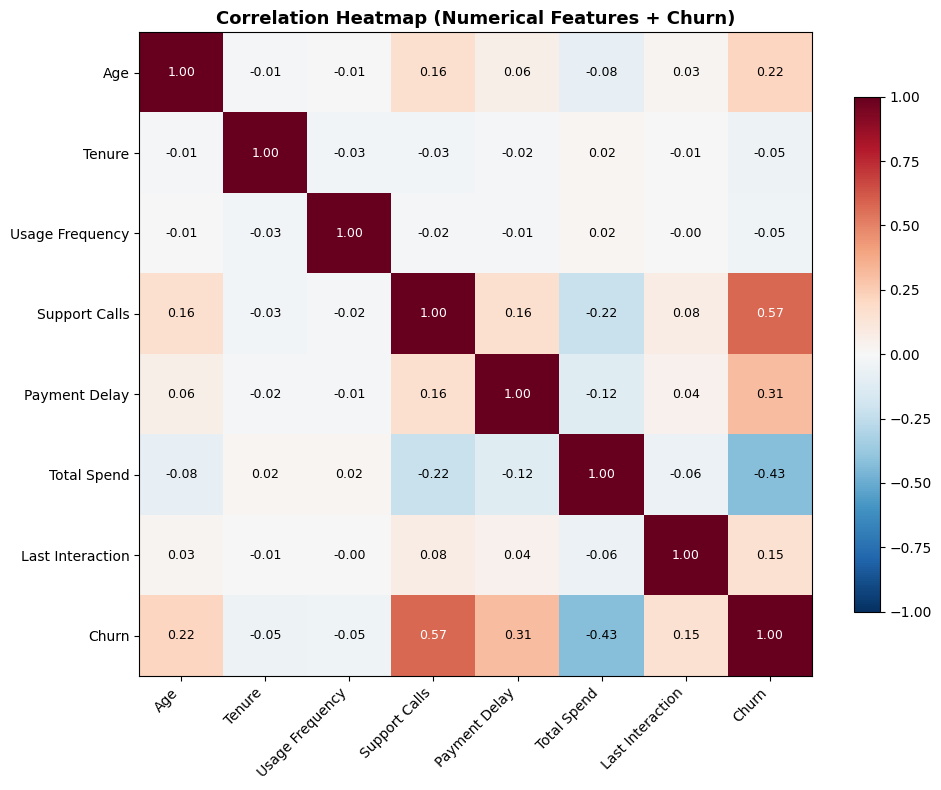


--- Correlation with Churn (sorted by |corr|) ---
  ↑ Support Calls        +0.5743
  ↓ Total Spend          -0.4294
  ↑ Payment Delay        +0.3121
  ↑ Age                  +0.2184
  ↑ Last Interaction     +0.1496
  ↓ Tenure               -0.0519
  ↓ Usage Frequency      -0.0461


In [13]:
# Tính correlation matrix (numerical columns + target)
corr_cols = num_cols + ["Churn"]
corr = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

# Annotate mỗi ô với giá trị correlation
for i in range(len(corr)):
    for j in range(len(corr)):
        color = "white" if abs(corr.iloc[i, j]) > 0.5 else "black"
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=9, color=color)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(corr.columns, fontsize=10)
ax.set_title("Correlation Heatmap (Numerical Features + Churn)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()


print("\n--- Correlation with Churn (sorted by |corr|) ---")
churn_corr = corr["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
for feat, val in churn_corr.items():
    direction = "↑" if val > 0 else "↓"
    print(f"  {direction} {feat:20s} {val:+.4f}")

### Numerical Features vs Churn (Boxplots)

So sánh phân bố của từng numerical feature giữa nhóm **Churn=0** và **Churn=1**.

Nếu boxplots **khác nhau rõ rệt** → feature đó có khả năng phân biệt Churn tốt.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26884\3172276386.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=["Not Churn", "Churn"],
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26884\3172276386.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=["Not Churn", "Churn"],
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26884\3172276386.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_0, data_1], labels=["Not Churn", "Churn"],
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26884\3172276386.py:9: MatplotlibDeprecatio

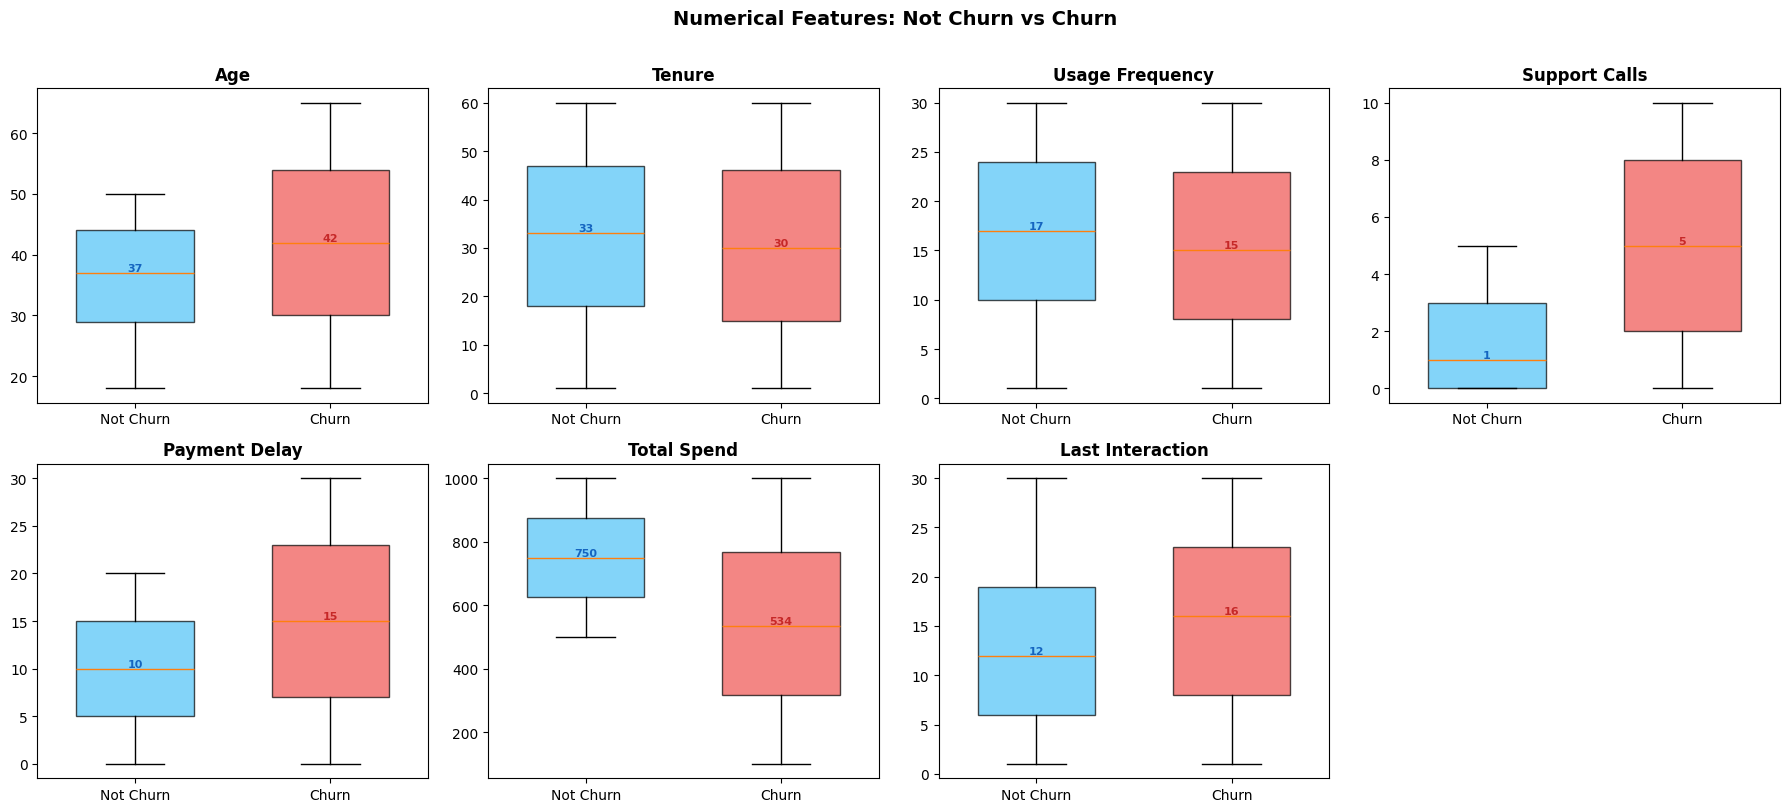

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
box_colors = ["#4FC3F7", "#EF5350"]

for i, col in enumerate(num_cols):
    ax = axes[i // 4][i % 4]
    data_0 = train_df[train_df["Churn"] == 0][col].dropna()
    data_1 = train_df[train_df["Churn"] == 1][col].dropna()

    bp = ax.boxplot([data_0, data_1], labels=["Not Churn", "Churn"],
                    patch_artist=True, widths=0.6)
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(col, fontweight="bold", fontsize=12)

    # Hiển thị median values
    ax.text(1, data_0.median(), f"{data_0.median():.0f}", ha="center",
            va="bottom", fontweight="bold", fontsize=8, color="#1565C0")
    ax.text(2, data_1.median(), f"{data_1.median():.0f}", ha="center",
            va="bottom", fontweight="bold", fontsize=8, color="#C62828")



axes[1][3].set_visible(False)
plt.suptitle("Numerical Features: Not Churn vs Churn",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Categorical Features vs Churn

Vẽ stacked bar chart để xem **tỷ lệ Churn** trong từng nhóm categorical.

Nếu tỷ lệ Churn **khác nhau rõ rệt** giữa các nhóm → feature đó hữu ích.

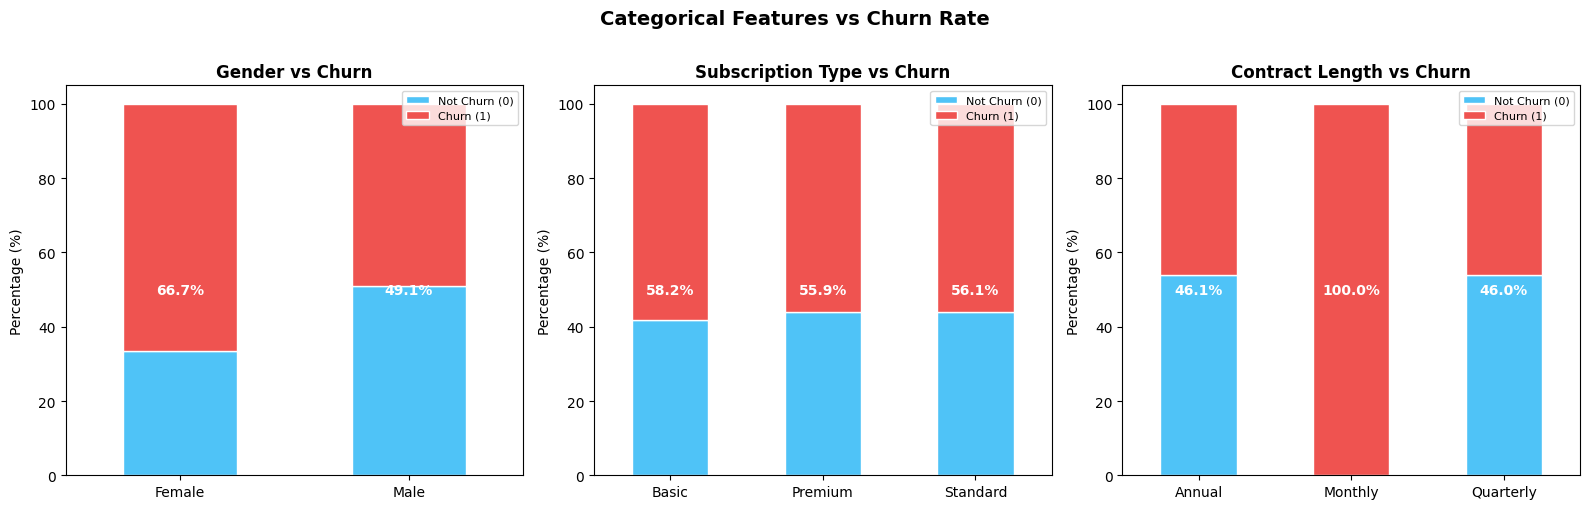

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(train_df[col].dropna(), train_df["Churn"].dropna(),
                     normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color=["#4FC3F7", "#EF5350"], edgecolor="white", linewidth=1)
    axes[i].set_title(f"{col} vs Churn", fontweight="bold", fontsize=12)
    axes[i].set_ylabel("Percentage (%)")
    axes[i].set_xlabel("")
    axes[i].legend(["Not Churn (0)", "Churn (1)"], loc="upper right", fontsize=8)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

    if 1.0 in ct.columns:
        for j, (idx, row) in enumerate(ct.iterrows()):
            churn_rate = row[1.0]
            axes[i].text(j, 50, f"{churn_rate:.1f}%",
                         ha="center", va="center", fontweight="bold",
                         fontsize=10, color="white")

plt.suptitle("Categorical Features vs Churn Rate",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### EDA Summary

| Insight | Chi tiết |
|---------|----------|
| Dataset size | Train: 440,832 × 12 (sau khi drop 1 missing) |
| Missing | 1 dòng (index 199295) → drop |
| Duplicates | 0 |
| Class balance | Churn=1: 56.7% / Churn=0: 43.3% → hơi imbalanced |
| Top features | Support Calls (+0.29), Payment Delay (+0.19) |
| Multicollinearity | Không có |
| Gender | Gần như không ảnh hưởng đến Churn |
| Contract Monthly | Churn rate cao nhất (~62%) |
| Subscription Basic | Churn rate cao nhất (~60%) |